# 06 - Advanced Analysis: Cohort Retention & Revenue Concentration
Covers two advanced techniques requested for the portfolio: **cohort retention** (window functions, self-joins) and **Pareto / running-total analysis**. Source SQL: `sql/08_advanced_analysis.sql`.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mticker, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook"); pd.set_option("display.width", 160)
ROOT = Path("..").resolve(); SQL = ROOT / "reports" / "sql_results"
def brl(x, pos=None): return f"R${x/1000:,.0f}k" if abs(x) >= 1000 else f"R${x:,.0f}"

## 1. Cohort retention
Customers are grouped into a monthly cohort by their **first valid purchase month**. For each cohort we track what % of those customers place another valid order in month 0, 1, 2, ... after joining.

**Limitation stated up front:** the dataset ends Oct 2018, so late cohorts (e.g. Aug 2018) have very few following months actually observed, and the overall repeat rate is only ~3% (notebook 04), so retention beyond month 0 is expected to be low for *every* cohort - this is a property of the business, not a modelling error.

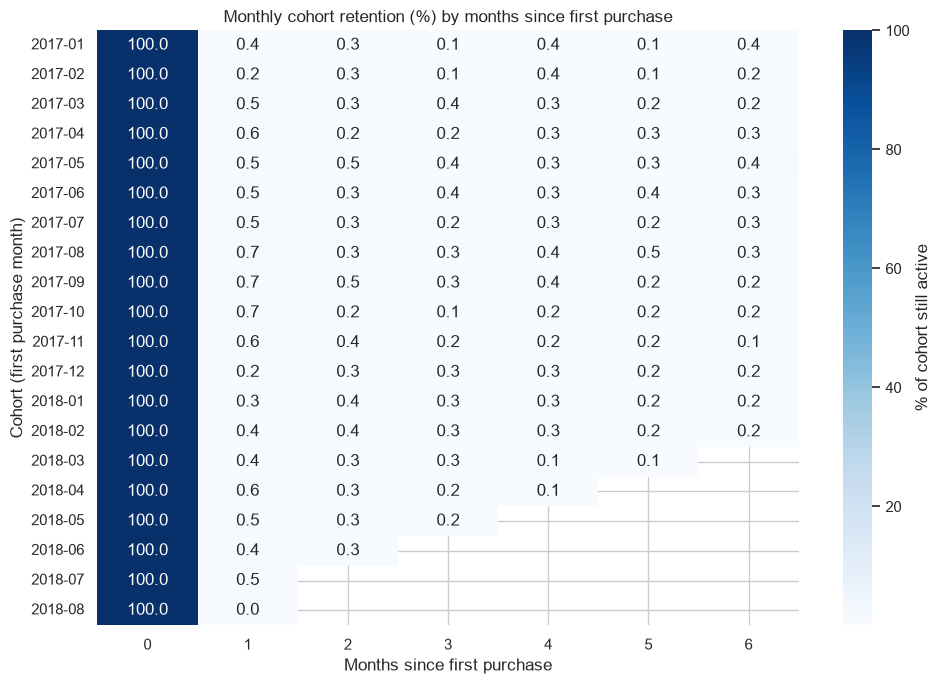

In [2]:
coh = pd.read_csv(SQL / "08_advanced_analysis__cohort_retention.csv", parse_dates=["cohort_month"])
pivot = coh.pivot(index="cohort_month", columns="month_number", values="retention_pct").sort_index()
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% of cohort still active"}, ax=ax)
ax.set_title("Monthly cohort retention (%) by months since first purchase"); ax.set_xlabel("Months since first purchase"); ax.set_ylabel("Cohort (first purchase month)")
ax.set_yticklabels([d.strftime("%Y-%m") for d in pivot.index])
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"cohort_retention_heatmap.png", dpi=110); plt.show()

In [3]:
m1 = pivot[1].dropna(); print(f"Average month-1 retention across cohorts: {m1.mean():.2f}%  (range {m1.min():.2f}% - {m1.max():.2f}%)")

Average month-1 retention across cohorts: 0.46%  (range 0.02% - 0.71%)


**Finding:** month-0 retention is 100% by definition; month-1 retention averages roughly 0.5-1% across cohorts, consistent with the ~3% overall repeat rate spread thinly across many months. No cohort stands out as meaningfully stickier than another. **Implication:** repeat purchase is not a reliable growth lever in this data; the business should be evaluated primarily on new-customer acquisition efficiency and average order value, not retention curves.

## 2. Revenue concentration: Pareto analysis

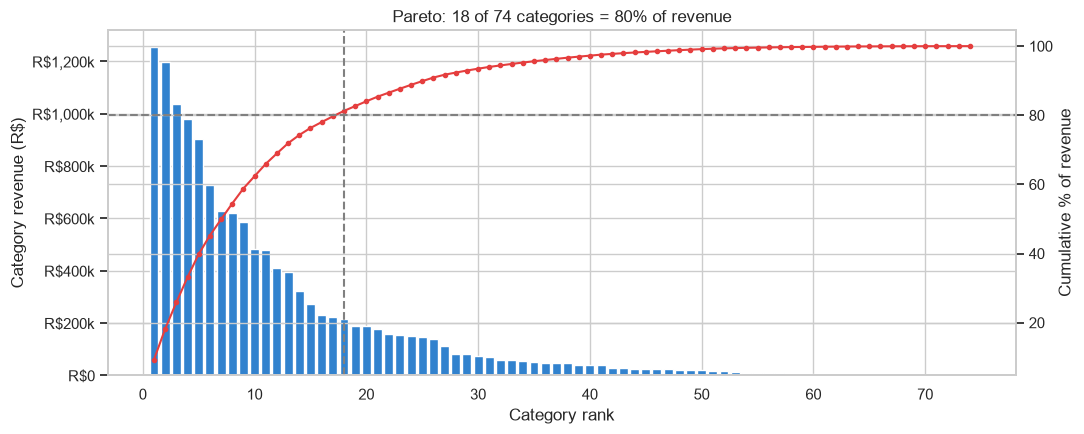

In [4]:
par = pd.read_csv(SQL / "08_advanced_analysis__category_pareto.csv")
summ = pd.read_csv(SQL / "08_advanced_analysis__pareto_summary.csv").iloc[0]
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(par.rnk, par.revenue_brl, color="#3182ce"); ax1.set_ylabel("Category revenue (R$)"); ax1.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax2 = ax1.twinx(); ax2.plot(par.rnk, par.cumulative_pct, color="#e53e3e", marker=".")
ax2.axhline(80, color="gray", ls="--"); ax2.axvline(summ.categories_for_80pct_revenue, color="gray", ls="--")
ax2.set_ylabel("Cumulative % of revenue"); ax1.set_xlabel("Category rank"); ax1.set_title(f"Pareto: {summ.categories_for_80pct_revenue} of {summ.total_categories} categories = 80% of revenue")
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"category_pareto.png", dpi=110); plt.show()

**Finding:** confirms the 04 notebook result numerically - 18 of 74 categories produce 80% of revenue. **Implication:** category management (pricing, promotions, seller recruitment) should be prioritised for this top group first.

## 3. Running revenue (cumulative growth)

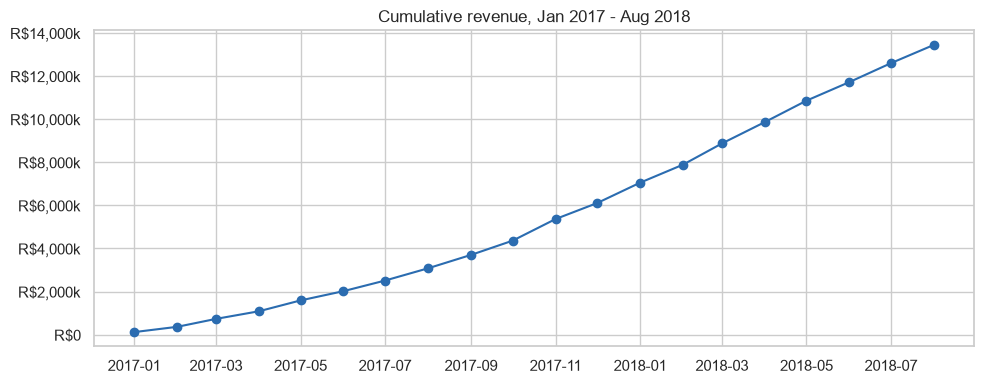

Cumulative revenue reached R$ 13,449,530 by Aug 2018


In [5]:
run = pd.read_csv(SQL / "08_advanced_analysis__running_revenue.csv", parse_dates=["month_start"])
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(run.month_start, run.running_revenue_brl, color="#2b6cb0", marker="o")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(brl)); ax.set_title("Cumulative revenue, Jan 2017 - Aug 2018")
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"running_revenue.png", dpi=110); plt.show()
print(f"Cumulative revenue reached R$ {run.running_revenue_brl.iloc[-1]:,.0f} by Aug 2018")

**Finding:** the running-total curve is steepest through H2 2017, flattening slightly (but still climbing) into 2018 - consistent with the plateau seen in notebook 03. Combined with the Pareto and cohort results, the clearest growth path is **new-customer acquisition into the top ~20 revenue categories**, since neither repeat purchases nor long-tail categories currently contribute much.